In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib
import os
import json

from sklearn.model_selection import train_test_split             
from sklearn.feature_extraction.text import TfidfVectorizer      
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [2]:
df_thr = pd.read_excel('../datasets/05_absa.xlsx')
df_thr.info()
df_thr.head()

<class 'pandas.DataFrame'>
RangeIndex: 1758 entries, 0 to 1757
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   platform          1758 non-null   str  
 1   text              1758 non-null   str  
 2   cleaning          1758 non-null   str  
 3   case_folding      1758 non-null   str  
 4   normalisasi_kata  1758 non-null   str  
 5   tokenize          1758 non-null   str  
 6   stopword removal  1758 non-null   str  
 7   stemming          1758 non-null   str  
 8   score             1758 non-null   int64
 9   sentiment         1758 non-null   str  
 10  keyword           1758 non-null   str  
dtypes: int64(1), str(10)
memory usage: 931.1 KB


,platform,text,cleaning,case_folding,normalisasi_kata,tokenize,stopword removal,stemming,score,sentiment,keyword
0,tiktok,asa te boga walikota..hanya KDM yg ku punya,asa te boga walikotahanya KDM yg ku punya,asa te boga walikotahanya kdm yg ku punya,"asa henteu boga wali kota, hanya kdm yang ku p...","['asa', 'henteu', 'boga', 'wali', 'kota,', 'ha...","asa henteu boga wali kota, kdm ku",asa henteu boga wali kota kdm ku,-1,Negatif,Kinerja Pemkot
1,tiktok,sedih gara gara bapak ini,sedih gara gara bapak ini,sedih gara gara bapak ini,sedih gara gara bapak ini,"['sedih', 'gara', 'gara', 'bapak', 'ini']",sedih gara gara,sedih gara gara,-3,Negatif,Kinerja Pemkot
2,tiktok,"hade goreng ku basa, ieu mah Pareum we eweuh k...",hade goreng ku basa ieu mah Pareum we eweuh kl...,hade goreng ku basa ieu mah pareum we eweuh kl...,hade goreng ku basa ieu mah pareum we eweuh kl...,"['hade', 'goreng', 'ku', 'basa', 'ieu', 'mah',...",hade goreng ku basa ieu mah pareum we eweuh kl...,hade goreng ku basa ieu mah pareum we eweuh kl...,-2,Negatif,Kinerja Pemkot
3,tiktok,Ciamis ts cair Minggu kmari .Tasik mah kmha ce...,Ciamis ts cair Minggu kmari Tasik mah kmha cer...,ciamis ts cair minggu kmari tasik mah kmha cer...,ciamis atos cair minggu kamari tasikmalaya mah...,"['ciamis', 'atos', 'cair', 'minggu', 'kamari',...",ciamis atos cair minggu kamari tasikmalaya mah...,ciamis atos cair minggu kamar tasikmalaya mah ...,0,Negatif,Lainnya
4,tiktok,nyesel milih dia,nyesel milih dia,nyesel milih dia,menyesal memilih dia,"['menyesal', 'memilih', 'dia']",menyesal memilih,sesal pilih,-1,Negatif,Lainnya


# **6. MODELING**

In [3]:
# Train test split

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

cleaned_data = df_thr.dropna(subset=['normalisasi_kata'])

X = cleaned_data['normalisasi_kata']
y = cleaned_data['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('Jumlah data train :', len(X_train))
print('Jumlah data test  :', len(X_test))

Jumlah data train : 1406
Jumlah data test  : 352


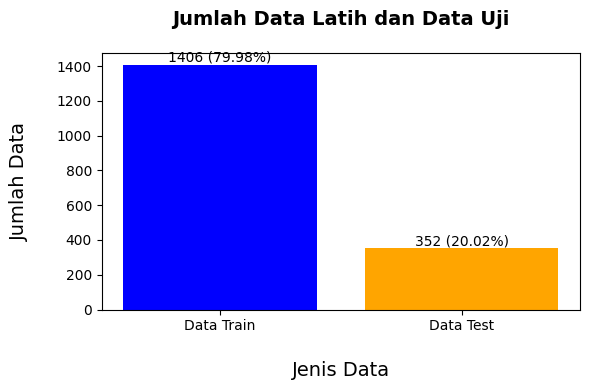

In [4]:
train_size = len(X_train)
test_size = len(X_test)

plt.figure(figsize=(6, 4))
bars = plt.bar(
    ['Data Train', 'Data Test'],
    [train_size, test_size],
    color=['blue', 'orange']
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f'{height} ({height / (train_size + test_size) * 100:.2f}%)',
        ha='center',
        va='bottom'
    )

plt.title('Jumlah Data Latih dan Data Uji', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Jenis Data', fontsize=14, labelpad=20)
plt.ylabel('Jumlah Data', fontsize=14, labelpad=20)
plt.tight_layout()
plt.savefig('../img/06 Jumlah Data Latih dan Data Uji.png')
plt.show()

In [5]:
# Vektorisasi

vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

X_train_vec.shape, X_test_vec.shape

print('Jumlah fitur data train setelah vektorisasi :', X_train_vec.shape[1])
print('Jumlah fitur data test setelah vektorisasi  :', X_test_vec.shape[1])

Jumlah fitur data train setelah vektorisasi : 3439
Jumlah fitur data test setelah vektorisasi  : 3439


In [6]:
# Using Model AI
models = {
    'SVM': SVC(kernel='linear', random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': MultinomialNB(),
    'Random Fores': RandomForestClassifier(random_state=42, n_estimators=100),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Neural Network': MLPClassifier(random_state=42, hidden_layer_sizes=(100,), max_iter=500),
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=42)
}

# Training and evaluation
results = {}

for model_name, model in models.items():
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)
    results[model_name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'classification_report': classification_report(y_test, y_pred, output_dict = True),
        'confusion_matrix': confusion_matrix(y_test, y_pred)
    }


Confusion Matrix for SVM:


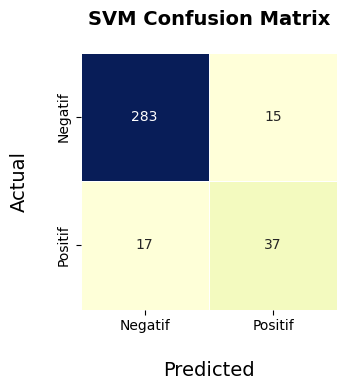


Confusion Matrix for KNN:


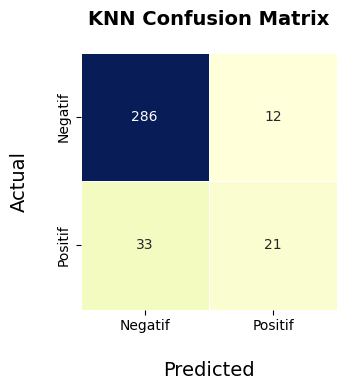


Confusion Matrix for Naive Bayes:


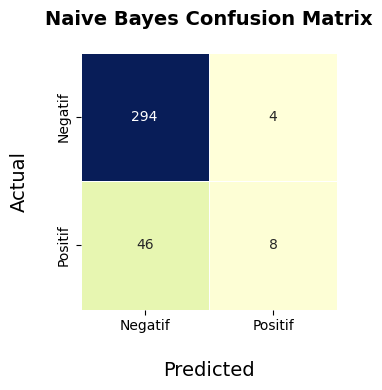


Confusion Matrix for Random Fores:


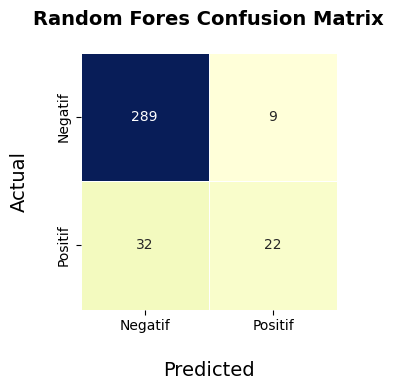


Confusion Matrix for Decision Tree:


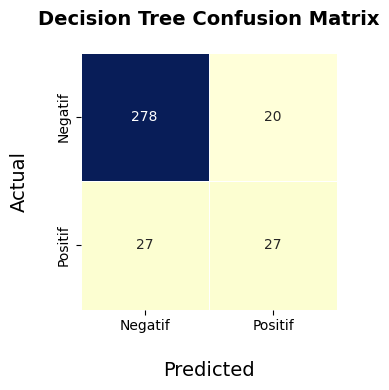


Confusion Matrix for Neural Network:


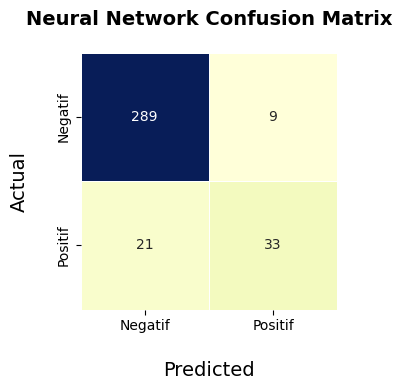


Confusion Matrix for Logistic Regression:


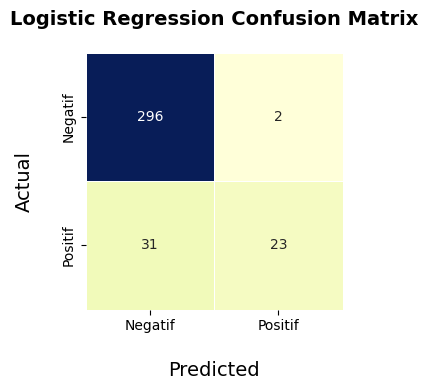

In [7]:
for model_name, result in results.items():
    fig, ax = plt.subplots(figsize=(4, 4))
    sns.heatmap(
        result['confusion_matrix'],
        annot=True,
        fmt='d',
        cmap='YlGnBu',
        cbar=False,
        xticklabels=['Negatif', 'Positif'],
        yticklabels=['Negatif', 'Positif'],
        ax=ax,
        square=True,
        linewidths=0.5
    )
    print(f'\nConfusion Matrix for {model_name}:')
    ax.set_title(f'{model_name} Confusion Matrix', fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel('Predicted', fontsize=14, labelpad=20)
    ax.set_ylabel('Actual', fontsize=14, labelpad=20)

    plt.tight_layout()
    plt.show()

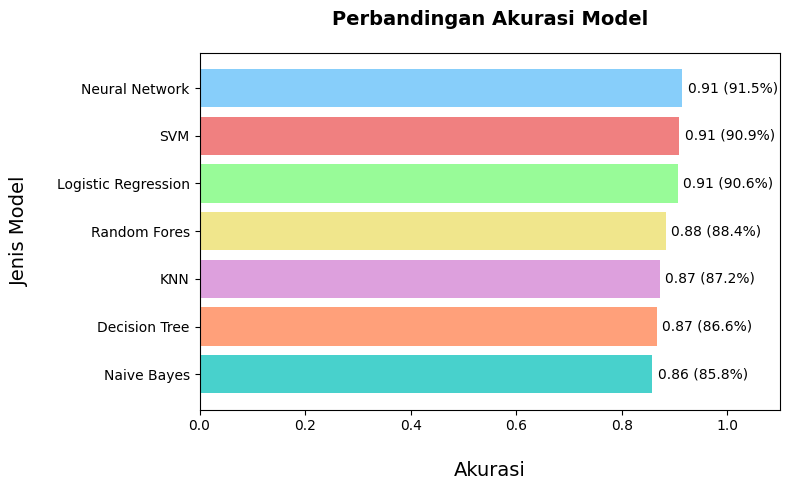

In [8]:
# Perbandingan hasil prediksi antar model

# Ambil nilai akurasi setiap model
accuracies = {
    model: result['accuracy']
    for model, result in results.items()
}

# Urutkan akurasi secara descending
sorted_accuracies = dict(
    sorted(
        accuracies.items(),
        key=lambda item: item[1],
        reverse=True
    )
)

# Warna bar
colors = [
    'lightskyblue',
    'lightcoral',
    'palegreen',
    'khaki',
    'plum',
    'lightsalmon',
    'mediumturquoise',
    'wheat'
]

# Sesuaikan jumlah warna dengan jumlah model
num_models = len(sorted_accuracies)

if num_models <= len(colors):
    bar_colors = colors[:num_models]
else:
    bar_colors = colors * (
        num_models // len(colors) + 1
    )

# Buat grafik
plt.figure(figsize=(8, 5))
bars = plt.barh(
    list(sorted_accuracies.keys()),
    list(sorted_accuracies.values()),
    color=bar_colors
)

# Tambahkan nilai akurasi di setiap bar
for bar in bars:
    accuracy = bar.get_width()

    plt.text(
        accuracy + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{accuracy:.2f} ({accuracy * 100:.1f}%)',
        va='center',
        fontsize=10
    )

# Pengaturan grafik
plt.title('Perbandingan Akurasi Model', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Akurasi', fontsize=14, labelpad=20)
plt.ylabel('Jenis Model', fontsize=14, labelpad=20)

# Akurasi berada pada rentang 0–1
plt.xlim(0, 1.1)

# Model dengan akurasi tertinggi berada di bagian atas
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [9]:
# Classification report

for model_name, result in results.items():
    print(f'\nClassification Report for {model_name} :')
    report_df = pd.DataFrame(result['classification_report']).transpose()
    styled_df = report_df.style.background_gradient(cmap='coolwarm')
    styled_df = styled_df.format(precision=3)
    display(styled_df)


Classification Report for SVM :


,precision,recall,f1-score,support
Negatif,0.943,0.950,0.946,298.000
Positif,0.712,0.685,0.698,54.000
accuracy,0.909,0.909,0.909,0.909
macro avg,0.827,0.817,0.822,352.000
weighted avg,0.908,0.909,0.908,352.000



Classification Report for KNN :


,precision,recall,f1-score,support
Negatif,0.897,0.960,0.927,298.000
Positif,0.636,0.389,0.483,54.000
accuracy,0.872,0.872,0.872,0.872
macro avg,0.766,0.674,0.705,352.000
weighted avg,0.857,0.872,0.859,352.000



Classification Report for Naive Bayes :


...

,precision,recall,f1-score,support
Negatif,0.911,0.933,0.922,298.000
Positif,0.574,0.500,0.535,54.000
accuracy,0.866,0.866,0.866,0.866
macro avg,0.743,0.716,0.728,352.000
weighted avg,0.860,0.866,0.863,352.000



Classification Report for Neural Network :


,precision,recall,f1-score,support
Negatif,0.932,0.970,0.951,298.000
Positif,0.786,0.611,0.688,54.000
accuracy,0.915,0.915,0.915,0.915
macro avg,0.859,0.790,0.819,352.000
weighted avg,0.910,0.915,0.910,352.000



Classification Report for Logistic Regression :


,precision,recall,f1-score,support
Negatif,0.905,0.993,0.947,298.000
Positif,0.920,0.426,0.582,54.000
accuracy,0.906,0.906,0.906,0.906
macro avg,0.913,0.710,0.765,352.000
weighted avg,0.907,0.906,0.891,352.000


# **SAVE MODEL**

### **1. Pemilihan best model**

In [10]:
import joblib
import os
from sklearn.pipeline import Pipeline

# Pemilihan best model berdasarkan F1 score (macro avg)
macro_f1_scores = {
    model_name: result['classification_report']['macro avg']['f1-score']
    for model_name, result in results.items()
}

best_model_name = max(macro_f1_scores, key=macro_f1_scores.get)
print(f'Model terbaik berdasarkan macro F1: {best_model_name} '
      f'(macro F1 = {macro_f1_scores[best_model_name]:.3f})')

Model terbaik berdasarkan macro F1: SVM (macro F1 = 0.822)


### **2. Bundel vectorizer**

In [11]:
best_model = models[best_model_name]

final_pipeline = Pipeline([
    ('vectorizer', vectorizer),
    ('classifier', best_model)
])

### **3. Save model**

In [12]:
# Buat folder baru
os.makedirs('../models', exist_ok=True)

model_path = f'../models/sentiment_pipeline_{best_model_name.lower().replace(" ", "_")}.joblib'
joblib.dump(final_pipeline, model_path)

print(f'Pipeline (vectorizer + model) disimpan di: {model_path}')

Pipeline (vectorizer + model) disimpan di: ../models/sentiment_pipeline_svm.joblib


### **4. Cek ukuran file**

In [13]:
size_mb = os.path.getsize(model_path) / (1024 * 1024)
print(f'Ukuran file : {size_mb:.2f} MB')

if size_mb > 50:
    print('File lebih dari 50mb')

Ukuran file : 0.11 MB


## **Save matrix model**

In [14]:
import json

metrics_summary = {}
for model_name, result in results.items():
    report = result['classification_report']
    metrics_summary[model_name] = {
        'accuracy': result['accuracy'],
        'macro_f1': report['macro avg']['f1-score'],
        'macro_precision': report['macro avg']['precision'],
        'macro_recall': report['macro avg']['recall'],
    }

os.makedirs('../models', exist_ok=True)
metrics_path = '../models/metrics.json'

with open(metrics_path, 'w', encoding='utf-8') as f:
    json.dump(metrics_summary, f, indent=2, ensure_ascii=False)

print(f"Metrik semua model disimpan di: {metrics_path}")
print(json.dumps(metrics_summary, indent=2))

Metrik semua model disimpan di: ../models/metrics.json
{
  "SVM": {
    "accuracy": 0.9090909090909091,
    "macro_f1": 0.8223007509307756,
    "macro_precision": 0.8274358974358975,
    "macro_recall": 0.8174248073576933
  },
  "KNN": {
    "accuracy": 0.8721590909090909,
    "macro_f1": 0.704912535628458,
    "macro_precision": 0.7664576802507836,
    "macro_recall": 0.674310216256525
  },
  "Naive Bayes": {
    "accuracy": 0.8579545454545454,
    "macro_f1": 0.5820271682340648,
    "macro_precision": 0.7656862745098039,
    "macro_recall": 0.5673626646781009
  },
  "Random Fores": {
    "accuracy": 0.8835227272727273,
    "macro_f1": 0.7257055972631379,
    "macro_precision": 0.8049944729172948,
    "macro_recall": 0.6886030325627641
  },
  "Decision Tree": {
    "accuracy": 0.8664772727272727,
    "macro_f1": 0.7283549250447433,
    "macro_precision": 0.7429717474712243,
    "macro_recall": 0.7164429530201342
  },
  "Neural Network": {
    "accuracy": 0.9147727272727273,
    "macro